Dataset loaded successfully!

DATASET SHAPE:
(7043, 21)

COLUMN NAMES:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

DATA TYPES:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtyp

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



MISSING VALUES BEFORE CLEANING:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

DUPLICATE ROWS:
0

MISSING VALUES IN TotalCharges AFTER CONVERSION:
11

DATASET SHAPE AFTER CLEANING:
(7032, 20)

MISSING VALUES AFTER CLEANING:
0

DATA TYPES AFTER CLEANING:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupp

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


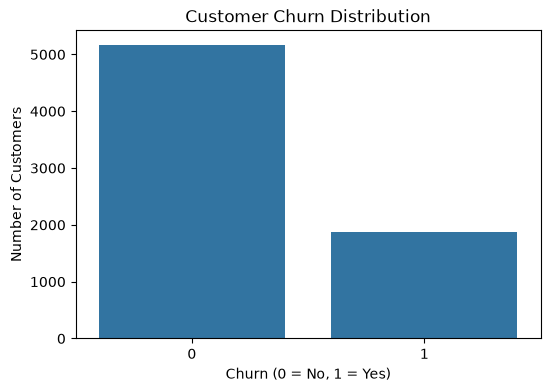

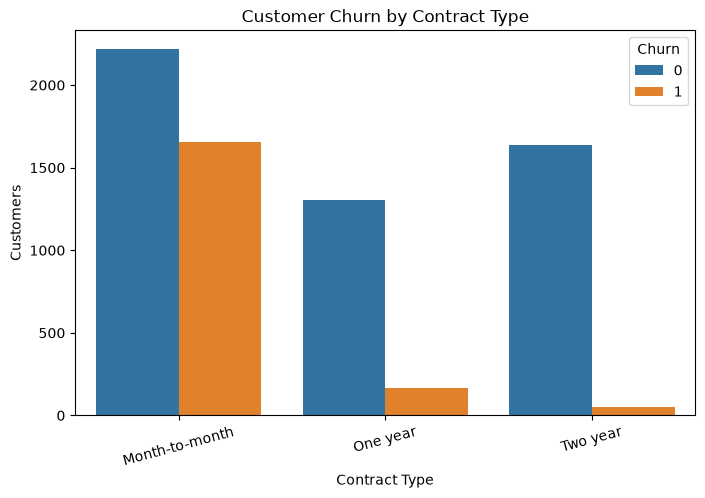

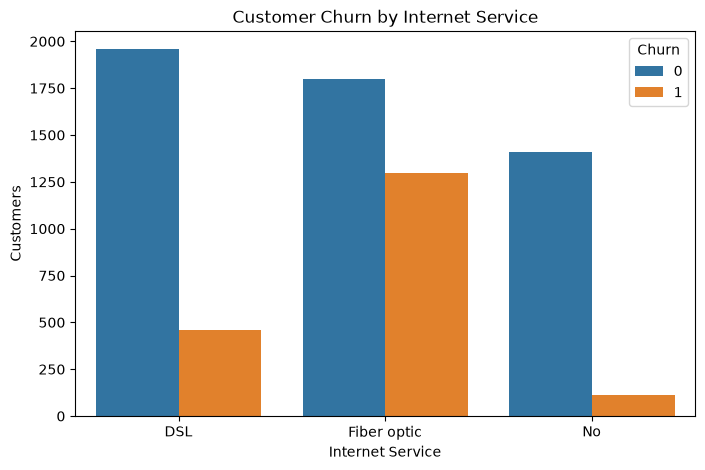

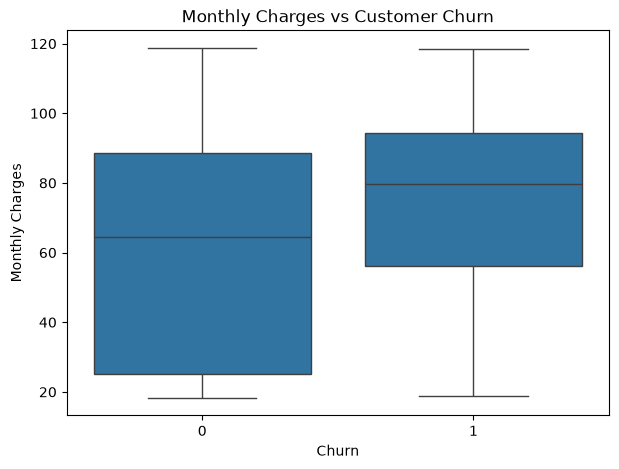

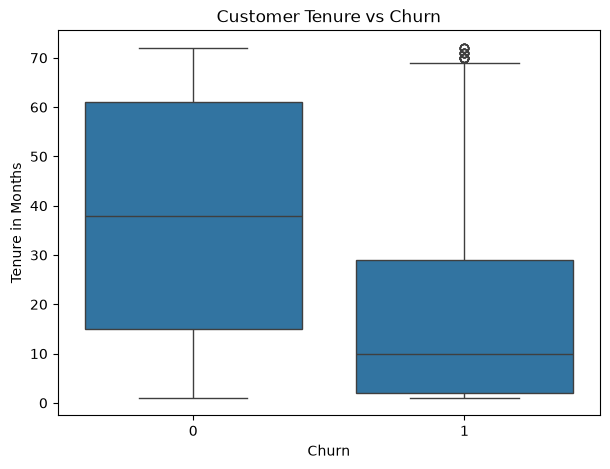


CHURN RATE BY CONTRACT:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64

CHURN RATE BY INTERNET SERVICE:
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Churn, dtype: float64

CHURN RATE BY PAYMENT METHOD:
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Churn, dtype: float64


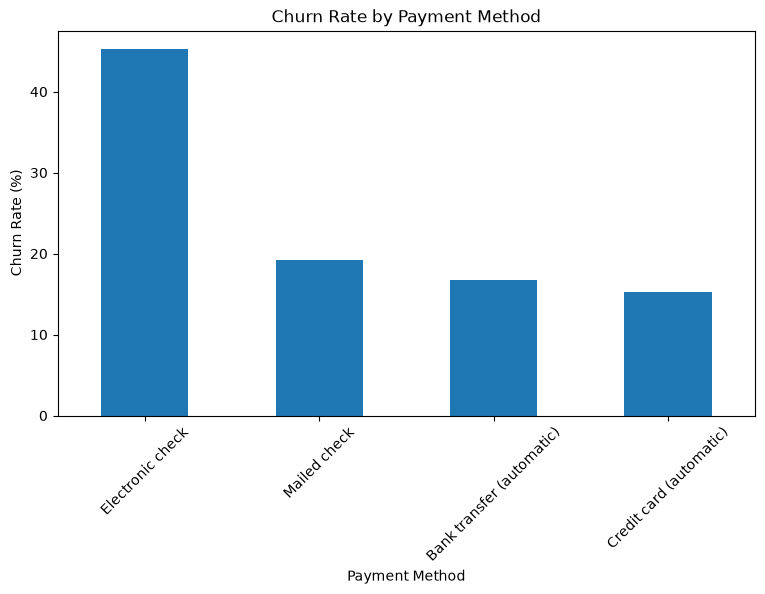

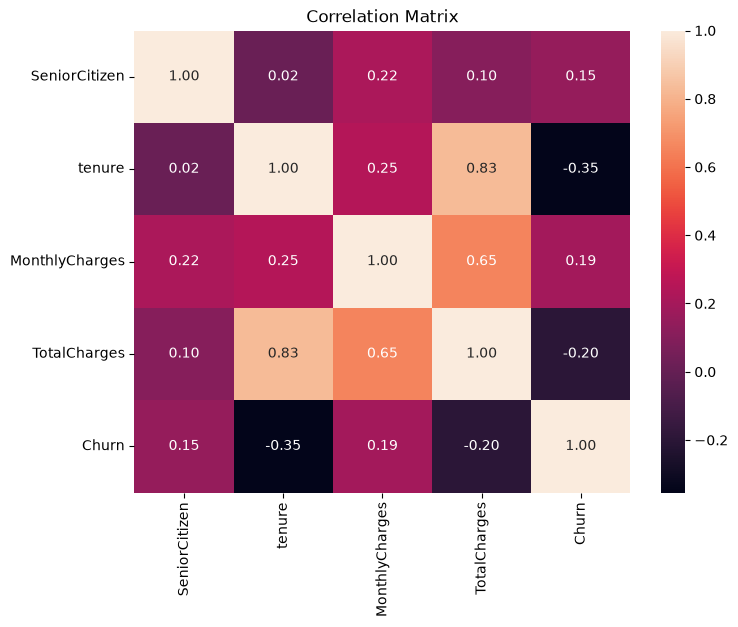


EDA AND DATA CLEANING COMPLETED SUCCESSFULLY!
Final dataset shape: (7032, 20)


In [3]:
# ============================================
# CUSTOMER CHURN PROJECT - EDA + DATA CLEANING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. LOAD DATASET
# --------------------------------------------

df = pd.read_csv("../Data/customer_churn.csv")

print("Dataset loaded successfully!\n")

# --------------------------------------------
# 2. BASIC DATASET INFORMATION
# --------------------------------------------

print("DATASET SHAPE:")
print(df.shape)

print("\nCOLUMN NAMES:")
print(df.columns.tolist())

print("\nDATA TYPES:")
print(df.dtypes)

print("\nFIRST 5 ROWS:")
display(df.head())

# --------------------------------------------
# 3. CHECK MISSING VALUES
# --------------------------------------------

print("\nMISSING VALUES BEFORE CLEANING:")
print(df.isnull().sum())

# --------------------------------------------
# 4. CHECK DUPLICATES
# --------------------------------------------

print("\nDUPLICATE ROWS:")
print(df.duplicated().sum())

# --------------------------------------------
# 5. FIX TotalCharges COLUMN
# --------------------------------------------

# TotalCharges is stored as object because some values are blank
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("\nMISSING VALUES IN TotalCharges AFTER CONVERSION:")
print(df["TotalCharges"].isnull().sum())

# Remove rows where TotalCharges is missing
df.dropna(subset=["TotalCharges"], inplace=True)

# --------------------------------------------
# 6. REMOVE DUPLICATES IF ANY
# --------------------------------------------

df.drop_duplicates(inplace=True)

# --------------------------------------------
# 7. REMOVE customerID
# --------------------------------------------

if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# --------------------------------------------
# 8. CONVERT TARGET VARIABLE
# --------------------------------------------

df["Churn"] = df["Churn"].map(
    {
        "Yes": 1,
        "No": 0
    }
)

# --------------------------------------------
# 9. DATA AFTER CLEANING
# --------------------------------------------

print("\nDATASET SHAPE AFTER CLEANING:")
print(df.shape)

print("\nMISSING VALUES AFTER CLEANING:")
print(df.isnull().sum().sum())

print("\nDATA TYPES AFTER CLEANING:")
print(df.dtypes)

# --------------------------------------------
# 10. TARGET DISTRIBUTION
# --------------------------------------------

print("\nCHURN COUNTS:")
print(df["Churn"].value_counts())

print("\nCHURN PERCENTAGE:")
print(
    (df["Churn"].value_counts(normalize=True) * 100).round(2)
)

# --------------------------------------------
# 11. NUMERICAL STATISTICS
# --------------------------------------------

print("\nNUMERICAL SUMMARY:")
display(df.describe())

# --------------------------------------------
# 12. CHURN DISTRIBUTION GRAPH
# --------------------------------------------

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

# --------------------------------------------
# 13. CHURN BY CONTRACT
# --------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customers")
plt.xticks(rotation=15)
plt.show()

# --------------------------------------------
# 14. CHURN BY INTERNET SERVICE
# --------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")
plt.show()

# --------------------------------------------
# 15. MONTHLY CHARGES VS CHURN
# --------------------------------------------

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

# --------------------------------------------
# 16. TENURE VS CHURN
# --------------------------------------------

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure in Months")
plt.show()

# --------------------------------------------
# 17. CHURN RATE BY CONTRACT
# --------------------------------------------

contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("\nCHURN RATE BY CONTRACT:")
print(contract_churn.round(2))

# --------------------------------------------
# 18. CHURN RATE BY INTERNET SERVICE
# --------------------------------------------

internet_churn = (
    df.groupby("InternetService")["Churn"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("\nCHURN RATE BY INTERNET SERVICE:")
print(internet_churn.round(2))

# --------------------------------------------
# 19. CHURN RATE BY PAYMENT METHOD
# --------------------------------------------

payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("\nCHURN RATE BY PAYMENT METHOD:")
print(payment_churn.round(2))

# --------------------------------------------
# 20. PAYMENT METHOD GRAPH
# --------------------------------------------

plt.figure(figsize=(9, 5))

payment_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

# --------------------------------------------
# 21. CORRELATION MATRIX
# --------------------------------------------

numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# --------------------------------------------
# 22. FINAL CHECK
# --------------------------------------------

print("\nEDA AND DATA CLEANING COMPLETED SUCCESSFULLY!")
print("Final dataset shape:", df.shape)

Machine Learning libraries loaded successfully!

Features shape: (7032, 19)
Target shape: (7032,)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Training samples: 5625
Testing samples: 1407

TRAINING LOGISTIC REGRESSION

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8359

TRAINING RANDOM FOREST


C:\Users\Abhi Ghanghas\AppData\Local\Temp\ipykernel_21752\284226709.py:54: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(



RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407

ROC-AUC: 0.8154

TRAINING XGBOOST

XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8311

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
2,XGBoost,0.7861,0.6137,0.5267,0.5669,0.8311
1,Random Forest,0.7605,0.5414,0.6471,0.5895,0.8154


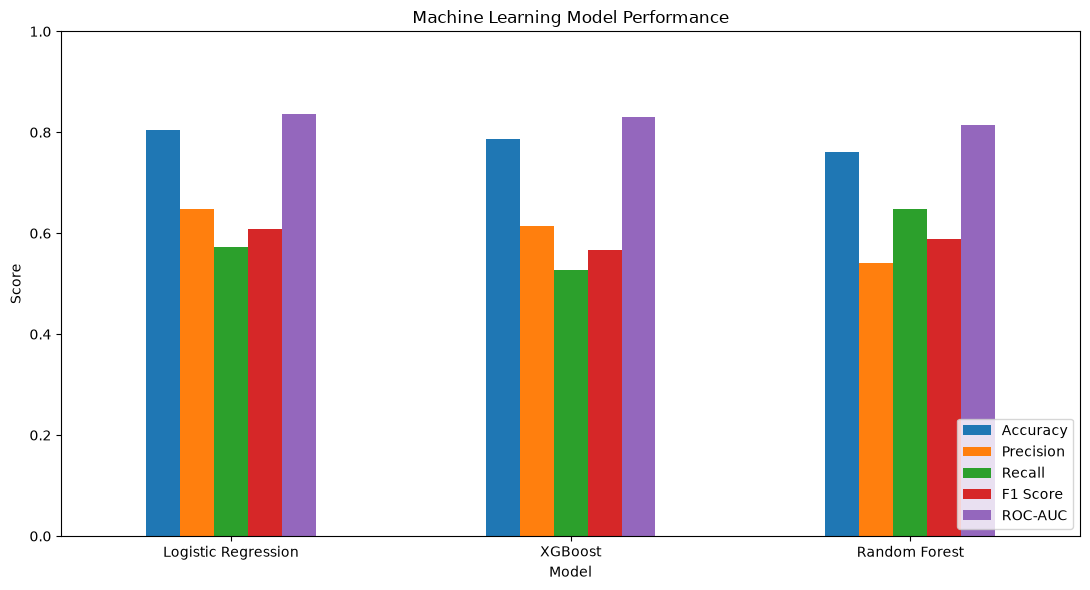

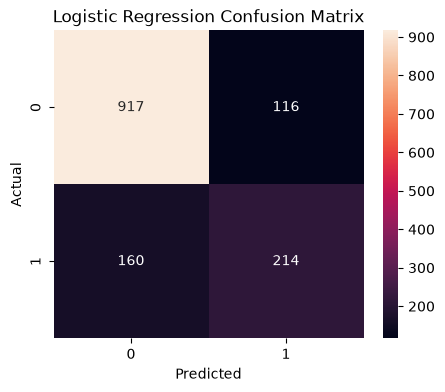

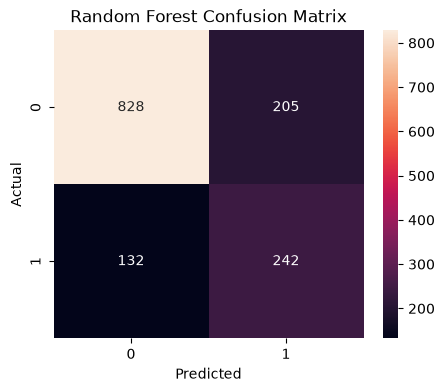

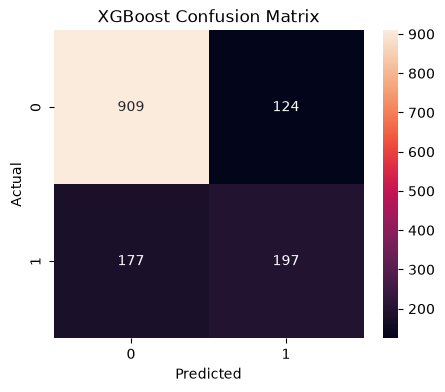


BEST MODEL
Best Model: Logistic Regression
ROC-AUC: 0.8359

Best model saved successfully!
Location: Models/churn_model.pkl

MACHINE LEARNING COMPLETED SUCCESSFULLY!


In [4]:
# ============================================================
# CUSTOMER CHURN PREDICTION - MACHINE LEARNING
# ============================================================

# ----------------------------
# 1. IMPORT ML LIBRARIES
# ----------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


print("Machine Learning libraries loaded successfully!")


# ============================================================
# 2. CREATE FEATURES AND TARGET
# ============================================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 3. IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()


print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 5. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

print("\n======================================")
print("TRAINING LOGISTIC REGRESSION")
print("======================================")

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


logistic_model.fit(
    X_train,
    y_train
)


logistic_predictions = logistic_model.predict(
    X_test
)

logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]


print("\nLOGISTIC REGRESSION RESULTS")

print(
    classification_report(
        y_test,
        logistic_predictions
    )
)


logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print(
    "ROC-AUC:",
    round(logistic_auc, 4)
)


# ============================================================
# 7. RANDOM FOREST
# ============================================================

print("\n======================================")
print("TRAINING RANDOM FOREST")
print("======================================")


random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)


random_forest_model.fit(
    X_train,
    y_train
)


rf_predictions = random_forest_model.predict(
    X_test
)

rf_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]


print("\nRANDOM FOREST RESULTS")

print(
    classification_report(
        y_test,
        rf_predictions
    )
)


rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print(
    "ROC-AUC:",
    round(rf_auc, 4)
)


# ============================================================
# 8. XGBOOST
# ============================================================

print("\n======================================")
print("TRAINING XGBOOST")
print("======================================")


xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


xgb_model.fit(
    X_train,
    y_train
)


xgb_predictions = xgb_model.predict(
    X_test
)

xgb_probabilities = xgb_model.predict_proba(
    X_test
)[:, 1]


print("\nXGBOOST RESULTS")

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)


xgb_auc = roc_auc_score(
    y_test,
    xgb_probabilities
)

print(
    "ROC-AUC:",
    round(xgb_auc, 4)
)


# ============================================================
# 9. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    name,
    y_true,
    predictions,
    probabilities
):

    return {

        "Model": name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions
        ),

        "Recall": recall_score(
            y_true,
            predictions
        ),

        "F1 Score": f1_score(
            y_true,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }


# ============================================================
# 10. COMPARE ALL MODELS
# ============================================================

results = []


results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)


results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)


results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_predictions,
        xgb_probabilities
    )
)


results_df = pd.DataFrame(
    results
)


results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)


print("\n======================================")
print("MODEL COMPARISON")
print("======================================")

display(
    results_df.round(4)
)


# ============================================================
# 11. MODEL COMPARISON GRAPH
# ============================================================

plot_df = results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]


plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)


plt.title(
    "Machine Learning Model Performance"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. CONFUSION MATRIX - LOGISTIC REGRESSION
# ============================================================

cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)


plt.figure(
    figsize=(5, 4)
)


sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d"
)


plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


# ============================================================
# 13. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)


plt.figure(
    figsize=(5, 4)
)


sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d"
)


plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


# ============================================================
# 14. CONFUSION MATRIX - XGBOOST
# ============================================================

cm_xgb = confusion_matrix(
    y_test,
    xgb_predictions
)


plt.figure(
    figsize=(5, 4)
)


sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d"
)


plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


# ============================================================
# 15. AUTOMATICALLY SELECT BEST MODEL
#     BASED ON ROC-AUC
# ============================================================

model_dictionary = {

    "Logistic Regression":
        logistic_model,

    "Random Forest":
        random_forest_model,

    "XGBoost":
        xgb_model
}


best_model_name = results_df.iloc[0][
    "Model"
]


best_model = model_dictionary[
    best_model_name
]


best_auc = results_df.iloc[0][
    "ROC-AUC"
]


print("\n======================================")
print("BEST MODEL")
print("======================================")


print(
    "Best Model:",
    best_model_name
)


print(
    "ROC-AUC:",
    round(best_auc, 4)
)


# ============================================================
# 16. SAVE BEST MODEL
# ============================================================

os.makedirs(
    "../Models",
    exist_ok=True
)


joblib.dump(
    best_model,
    "../Models/churn_model.pkl"
)


print(
    "\nBest model saved successfully!"
)


print(
    "Location: Models/churn_model.pkl"
)


# ============================================================
# 17. FINAL MESSAGE
# ============================================================

print(
    "\n======================================"
)

print(
    "MACHINE LEARNING COMPLETED SUCCESSFULLY!"
)

print(
    "======================================"
)

Starting model explainability...

Best Model: Logistic Regression

Number of transformed features:
45

TOP 20 MOST IMPORTANT FEATURES:


,Feature,Coefficient,Absolute Importance
1,num__tenure,-1.352313,1.352313
38,cat__Contract_Two year,-0.779030,0.779030
3,num__TotalCharges,0.644014,0.644014
15,cat__InternetService_DSL,-0.616132,0.616132
36,cat__Contract_Month-to-month,0.613846,0.613846
16,cat__InternetService_Fiber optic,0.590184,0.590184
2,num__MonthlyCharges,-0.541006,0.541006
39,cat__PaperlessBilling_No,-0.300387,0.300387
12,cat__MultipleLines_No,-0.293470,0.293470
17,cat__InternetService_No,-0.283724,0.283724



TOP FEATURES INCREASING CHURN:


,Feature,Coefficient
3,num__TotalCharges,0.644014
36,cat__Contract_Month-to-month,0.613846
16,cat__InternetService_Fiber optic,0.590184
32,cat__StreamingTV_Yes,0.191113
43,cat__PaymentMethod_Electronic check,0.180671
35,cat__StreamingMovies_Yes,0.177076
18,cat__OnlineSecurity_No,0.164459
27,cat__TechSupport_No,0.142949
14,cat__MultipleLines_Yes,0.088164
0,num__SeniorCitizen,0.071011



TOP FEATURES REDUCING CHURN:


,Feature,Coefficient
1,num__tenure,-1.352313
38,cat__Contract_Two year,-0.779030
15,cat__InternetService_DSL,-0.616132
2,num__MonthlyCharges,-0.541006
39,cat__PaperlessBilling_No,-0.300387
12,cat__MultipleLines_No,-0.293470
17,cat__InternetService_No,-0.283724
19,cat__OnlineSecurity_No internet service,-0.283724
25,cat__DeviceProtection_No internet service,-0.283724
31,cat__StreamingTV_No internet service,-0.283724


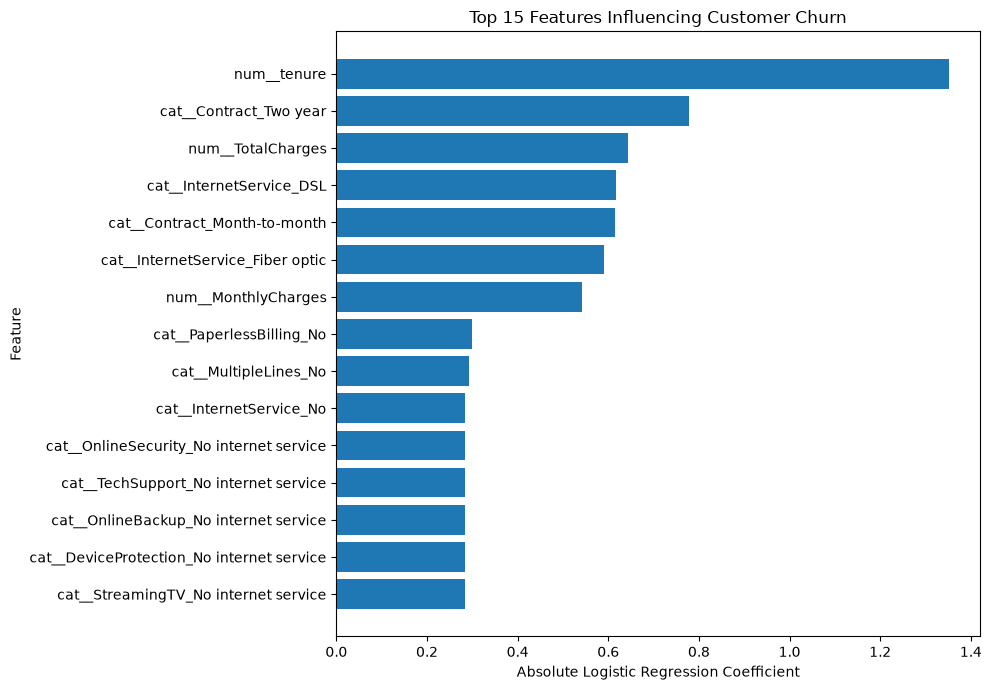

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.



Creating SHAP explainer...
SHAP values generated successfully!


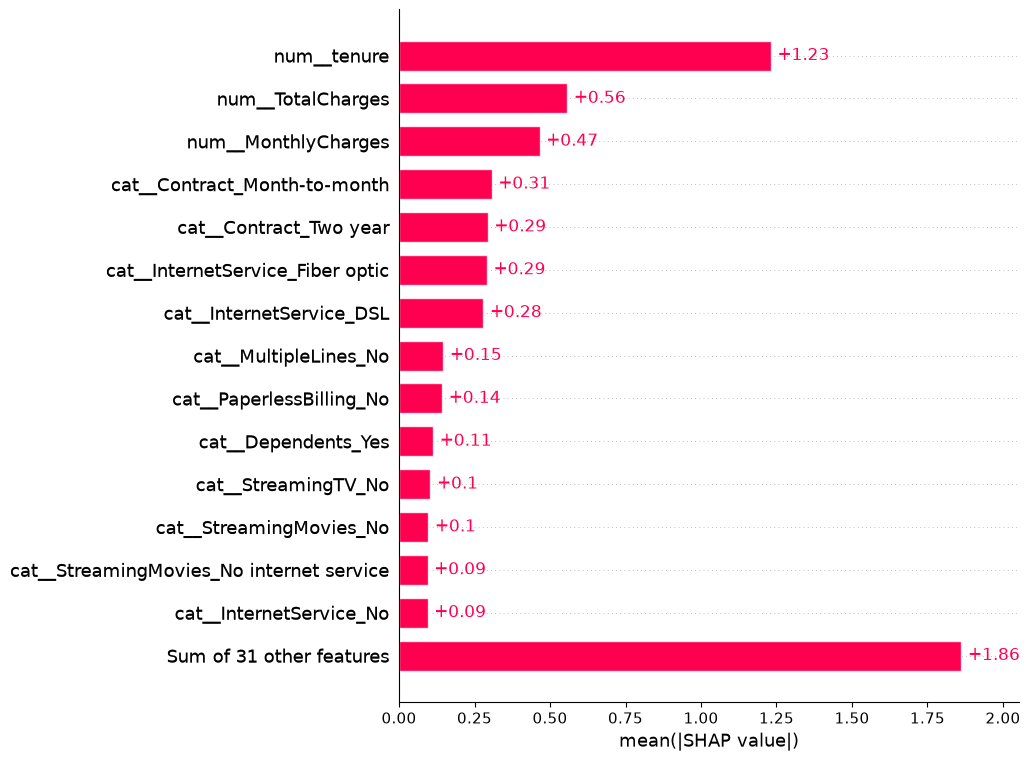

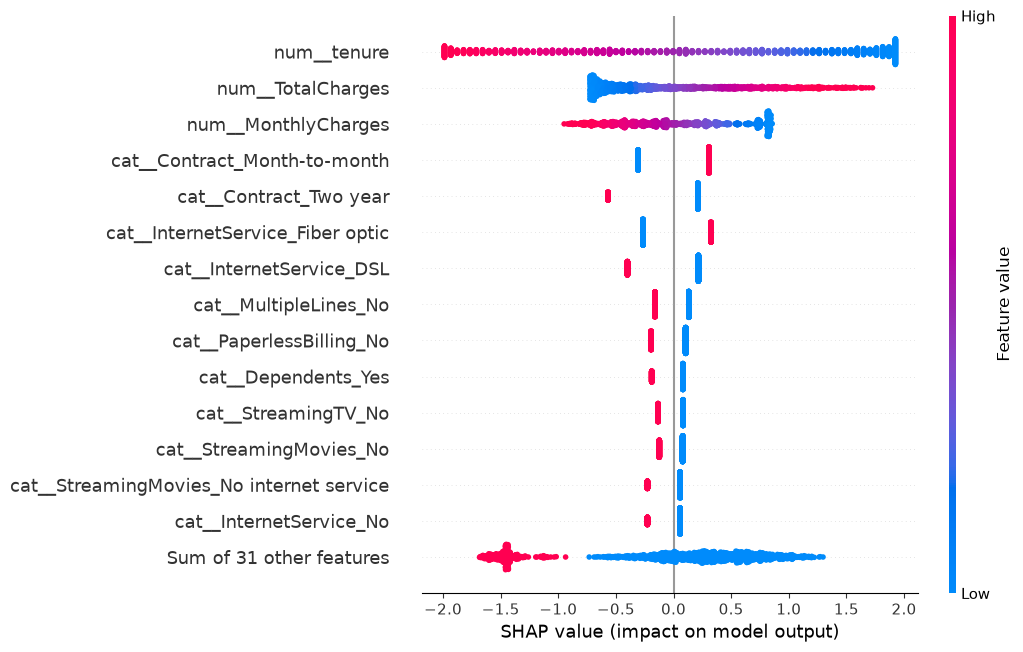


Explaining customer: 0

Original Customer Information:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
974,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),75.95,4542.35



Actual Churn: 0
Predicted Churn: 0
Churn Probability: 1.75 %


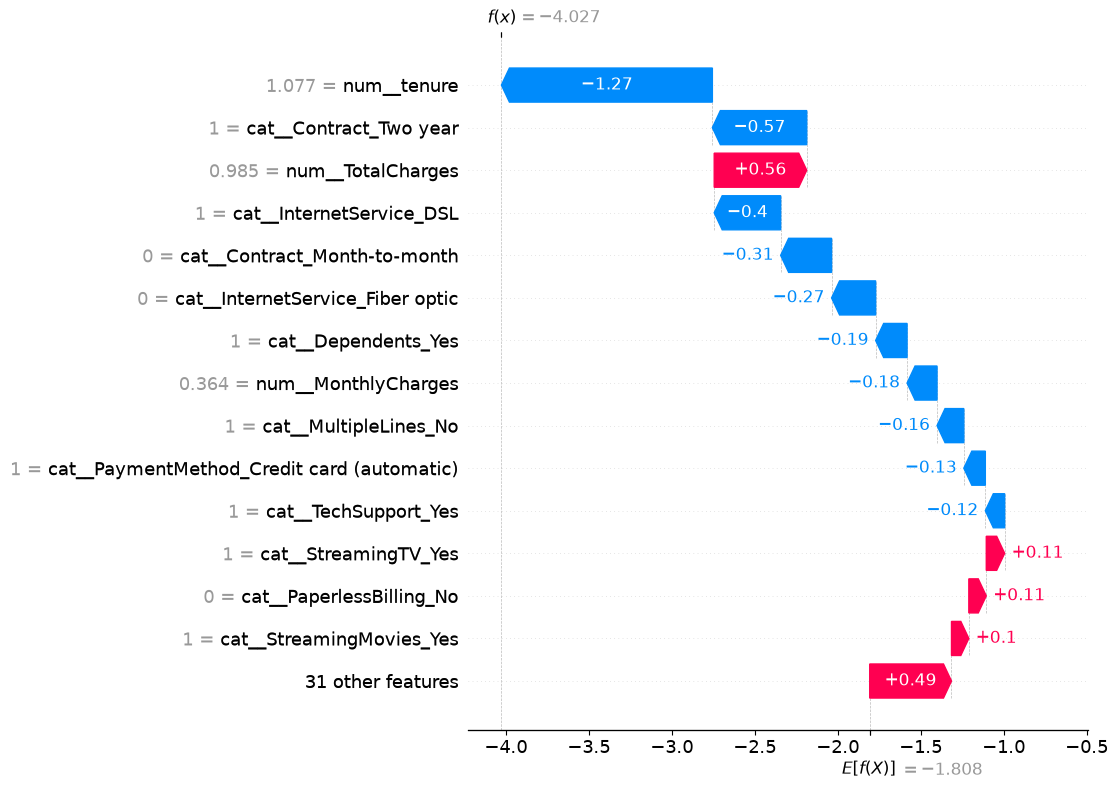


Feature importance saved:
Models/feature_importance.csv

MODEL EXPLAINABILITY COMPLETED!


In [5]:
# ============================================================
# CUSTOMER CHURN PROJECT - MODEL EXPLAINABILITY
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


print("Starting model explainability...")


# ============================================================
# 1. GET BEST MODEL COMPONENTS
# ============================================================

trained_preprocessor = best_model.named_steps["preprocessor"]
trained_classifier = best_model.named_steps["classifier"]


print("\nBest Model:", best_model_name)


# ============================================================
# 2. TRANSFORM TEST DATA
# ============================================================

X_test_transformed = trained_preprocessor.transform(X_test)

feature_names = trained_preprocessor.get_feature_names_out()


print("\nNumber of transformed features:")
print(len(feature_names))


# ============================================================
# 3. CREATE FEATURE COEFFICIENT TABLE
#    LOGISTIC REGRESSION INTERPRETATION
# ============================================================

if best_model_name == "Logistic Regression":

    coefficients = trained_classifier.coef_[0]

    coefficient_df = pd.DataFrame(
        {
            "Feature": feature_names,
            "Coefficient": coefficients,
            "Absolute Importance": np.abs(coefficients)
        }
    )

    coefficient_df = coefficient_df.sort_values(
        by="Absolute Importance",
        ascending=False
    )

    print("\nTOP 20 MOST IMPORTANT FEATURES:")

    display(
        coefficient_df.head(20)
    )


    # ========================================================
    # 4. TOP POSITIVE CHURN DRIVERS
    # ========================================================

    positive_features = coefficient_df[
        coefficient_df["Coefficient"] > 0
    ].sort_values(
        "Coefficient",
        ascending=False
    ).head(10)


    print("\nTOP FEATURES INCREASING CHURN:")

    display(
        positive_features[
            ["Feature", "Coefficient"]
        ]
    )


    # ========================================================
    # 5. TOP NEGATIVE CHURN DRIVERS
    # ========================================================

    negative_features = coefficient_df[
        coefficient_df["Coefficient"] < 0
    ].sort_values(
        "Coefficient",
        ascending=True
    ).head(10)


    print("\nTOP FEATURES REDUCING CHURN:")

    display(
        negative_features[
            ["Feature", "Coefficient"]
        ]
    )


    # ========================================================
    # 6. PLOT MOST IMPORTANT FEATURES
    # ========================================================

    top_features = coefficient_df.head(15).sort_values(
        "Absolute Importance",
        ascending=True
    )


    plt.figure(
        figsize=(10, 7)
    )


    plt.barh(
        top_features["Feature"],
        top_features["Absolute Importance"]
    )


    plt.title(
        "Top 15 Features Influencing Customer Churn"
    )

    plt.xlabel(
        "Absolute Logistic Regression Coefficient"
    )

    plt.ylabel(
        "Feature"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 7. SHAP EXPLAINABILITY
# ============================================================

print("\nCreating SHAP explainer...")


# Use a smaller background sample for efficiency
background_size = min(
    300,
    len(X_train)
)


X_train_transformed = trained_preprocessor.transform(
    X_train
)


background = X_train_transformed[
    :background_size
]


explainer = shap.Explainer(
    trained_classifier,
    background,
    feature_names=feature_names
)


# Explain test samples
shap_values = explainer(
    X_test_transformed
)


print(
    "SHAP values generated successfully!"
)


# ============================================================
# 8. GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap.plots.bar(
    shap_values,
    max_display=15
)


# ============================================================
# 9. SHAP BEESWARM PLOT
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=15
)


# ============================================================
# 10. EXPLAIN ONE INDIVIDUAL CUSTOMER
# ============================================================

customer_number = 0


print(
    "\nExplaining customer:",
    customer_number
)


print(
    "\nOriginal Customer Information:"
)


display(
    X_test.iloc[
        [customer_number]
    ]
)


print(
    "\nActual Churn:",
    y_test.iloc[
        customer_number
    ]
)


prediction = best_model.predict(
    X_test.iloc[
        [customer_number]
    ]
)[0]


probability = best_model.predict_proba(
    X_test.iloc[
        [customer_number]
    ]
)[0][1]


print(
    "Predicted Churn:",
    prediction
)


print(
    "Churn Probability:",
    round(
        probability * 100,
        2
    ),
    "%"
)


# Individual explanation
shap.plots.waterfall(
    shap_values[
        customer_number
    ],
    max_display=15
)


# ============================================================
# 11. SAVE FEATURE IMPORTANCE
# ============================================================

os.makedirs(
    "../Models",
    exist_ok=True
)


if best_model_name == "Logistic Regression":

    coefficient_df.to_csv(
        "../Models/feature_importance.csv",
        index=False
    )


    print(
        "\nFeature importance saved:"
    )

    print(
        "Models/feature_importance.csv"
    )


# ============================================================
# 12. FINAL MESSAGE
# ============================================================

print(
    "\n=========================================="
)

print(
    "MODEL EXPLAINABILITY COMPLETED!"
)

print(
    "=========================================="
)